<a href="https://colab.research.google.com/github/hcc7402/Test/blob/linewidth/locklinewidth_calc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# reference: https://opg.optica.org/viewmedia.cfm?r=1&rwjcode=ao&uri=ao-49-25-4801&html=true

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import welch

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

FILE = Path('/content/drive/MyDrive/Colab Notebooks/plc1_filtered.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# load csv file
df = pd.read_csv(FILE, sep=None, engine="python", skip_blank_lines=True)
if df.shape[0] >= 1 and not pd.to_numeric(pd.Series([df.iloc[0,0]]), errors="coerce").notna().all():
    df = df.iloc[1:].reset_index(drop=True)
for c in df.columns:
    df[c] = pd.to_numeric(df[c], errors="coerce")

#print(df)

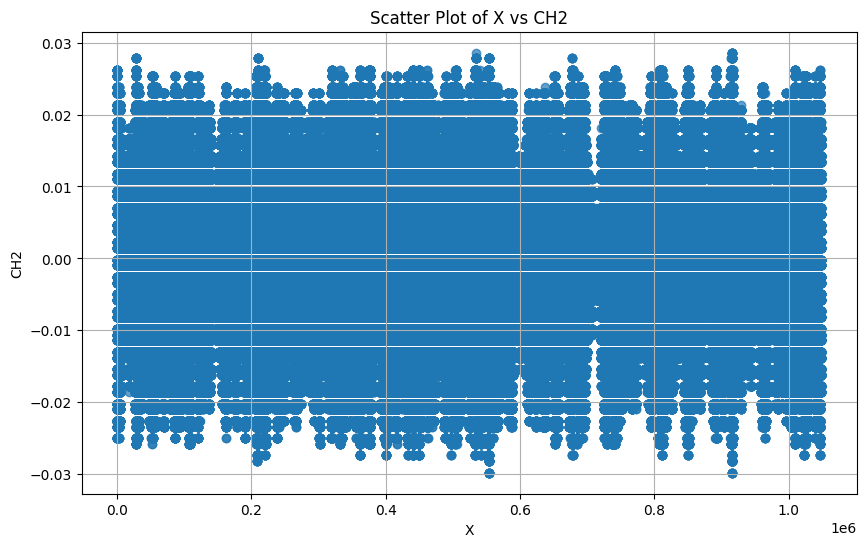

In [ ]:
# plots

plt.figure(figsize=(10, 6))
plt.scatter(df['X'], df['CH2'], alpha=0.7)
plt.title('Scatter Plot of X vs CH2')
plt.xlabel('X')
plt.ylabel('CH2')
plt.grid(True)
plt.show()

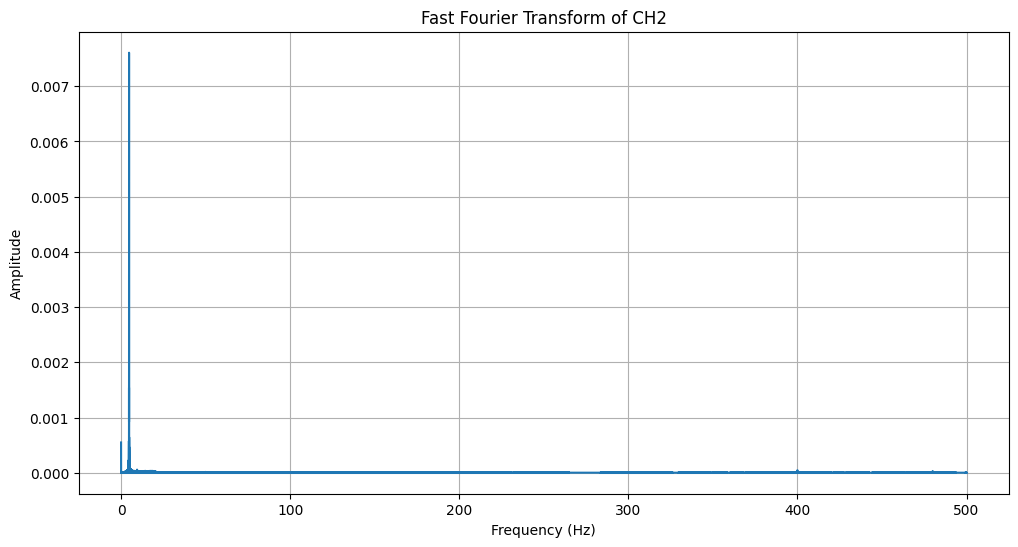

In [ ]:
# Perform FFT on CH2
ch2_data = df['CH2'].values
fs = 1.0e3    # sample rate (Hz)

# Compute the FFT
N = len(ch2_data) # Number of samples
yf = np.fft.fft(ch2_data)
xf = np.fft.fftfreq(N, 1 / fs) # Frequencies corresponding to the FFT output

# Plot the magnitude of the FFT
plt.figure(figsize=(12, 6))
plt.plot(xf[:N // 2], 2.0/N * np.abs(yf[0:N // 2])) # Plot only positive frequencies
plt.title('Fast Fourier Transform of CH2')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()

In [ ]:
f, S_ee = welch(ch2_data, fs=fs, window='hann', nperseg=2**10, noverlap=2**9)
K_err = 2.50e-6   # V/Hz conversion
Snu = S_ee / (K_err**2)   # Hz^2/Hz

In [ ]:
# β-separation linewidth calc

Sbeta = (8*np.log(2)/np.pi**2)*f
T0 = len(ch2_data)/fs   # observation time
f_low = 1.0/T0
mask = (f>=f_low) & (Snu>Sbeta)
A = np.trapz(Snu[mask], f[mask])
FWHM_beta = np.sqrt(8*np.log(2)*A)    # Hz

print(f"β-separation FWHM ≈ {FWHM_beta/1e3:.2f} kHz")

β-separation FWHM ≈ 11.96 kHz


/tmp/ipython-input-1151406314.py:7: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  A = np.trapz(Snu[mask], f[mask])
